# Lab 8b: Multi-Digit Memory and Mixing Time Analysis

In this lab, we extend the stochastic attention example from L8a by storing multiple digit classes in a single memory matrix. We test whether the modern Hopfield network can retrieve the correct digit class from corrupted inputs, measure retrieval accuracy as a function of the inverse temperature $\beta$, and track convergence dynamics step-by-step using the Langevin trajectory.

> __Learning Objectives__
>
> By the end of this lab, you should be able to:
> * __Build a multi-class memory matrix and retrieve stored patterns:__ Construct a memory matrix containing images from multiple MNIST digit classes and run deterministic attention retrieval on corrupted inputs. Verify that the network recovers the correct digit class even when multiple classes compete for attention.
> * __Measure retrieval accuracy across digit classes and beta values:__ Corrupt stored memories, classify each retrieval by nearest-neighbor matching, and compute per-class and overall accuracy. Observe how decreasing $\beta$ degrades retrieval accuracy as the network transitions from recall to generation.
> * __Analyze mixing time through trajectory tracking:__ Record the full Langevin trajectory and compute the cosine similarity to the nearest stored memory at each step. Compare convergence speed across different $\beta$ values and connect the mixing behavior to the retrieval-generation spectrum.

Let's get started!

___

## Setup, Data, and Prerequisites

We set up the computational environment by including the `Include.jl` file, loading any needed resources, such as sample datasets, and setting up any required constants.

> __Environment Setup with Include.jl__
>
> The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file, `Include.jl`, in the notebook's global scope. The `Include.jl` file sets paths, loads required external packages, and includes local source files in `src/`. For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/).

Let's set up our code environment:

In [1]:
include(joinpath(@__DIR__, "Include.jl")); # include the Include.jl file

In addition to standard Julia libraries, we'll also use [the `VLDataScienceMachineLearningPackage.jl` package](https://github.com/varnerlab/VLDataScienceMachineLearningPackage.jl). Check out [the documentation](https://varnerlab.github.io/VLDataScienceMachineLearningPackage.jl/dev/) for more information on the functions, types, and data used in this material.

### Implementations

The notebook uses a local `decode(...)` function to convert flattened state vectors back to image format:

> * `decode(s; number_of_rows, number_of_cols)`: Converts a flattened state vector $\mathbf{s}$ back to an $n \times n$ image matrix. Reshapes the vector, transposes it to match row-major ordering, and clamps values to $[0,1]$ for grayscale display.

Let's define this helper function.

In [2]:
function decode(s::Vector{<:Number}; number_of_rows::Int=28, number_of_cols::Int=28)::Array{Float32,2}
    X = reshape(s, number_of_rows, number_of_cols) |> X -> transpose(X) |> Matrix;
    X̂ = clamp.(Float32.(X), 0.0f0, 1.0f0);
    return X̂
end

decode (generic function with 1 method)

### Constants
Let's set some constants that define the problem size and dataset parameters. The comment next to each constant describes its purpose and values:

In [3]:
target_digits = [3, 7, 9];                                  # which digit classes to store as memories
K_per_class = 32;                                           # number of images per digit class
number_of_examples = 1000;                                  # how many examples per digit to load from MNIST
number_of_rows = 28;                                        # number of rows in an MNIST image
number_of_cols = 28;                                        # number of cols in an MNIST image
number_of_pixels = number_of_rows * number_of_cols;         # total pixels per image (784)
η = 0.5;                                                    # step size for the attention update
T_steps = 200;                                              # number of update steps per trajectory
θ = 0.50;                                                   # fraction of pixels to corrupt

___

## Task 1: Build a Multi-Digit Memory Matrix and Retrieve Stored Patterns
In this task, we load MNIST digit images from multiple classes, build a combined memory matrix $\mathbf{X}\in\mathbb{R}^{N\times K}$ where $K = K_{\text{per class}}\times|\text{classes}|$, corrupt a stored memory, and use deterministic attention to recover it.

### Load the MNIST digits dataset
We load the MNIST handwritten digit dataset using `MyMNISTHandwrittenDigitImageDataset(...)`. This returns a dictionary where keys are digit labels (0 to 9) and values are 3D arrays of shape $(28, 28, K)$ holding $K$ grayscale images.

Let's load the dataset and preview a few examples from each target class.

In [4]:
digits_image_dictionary = MyMNISTHandwrittenDigitImageDataset(number_of_examples = number_of_examples);

Let's preview a few examples from each digit class we plan to store:

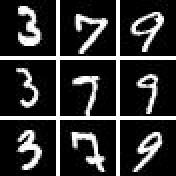

In [5]:
let
    examples = [1, 5, 10];
    all_imgs = [];
    for d in target_digits
        for i in examples
            push!(all_imgs, Gray.(digits_image_dictionary[d][:, :, i]));
        end
    end
    mosaicview(all_imgs..., nrow=length(target_digits), npad=2, fillvalue=Gray(1.0))
end

### Build the multi-class memory matrix
We select $K_{\text{per class}}$ examples from each target digit class, flatten each $28\times 28$ image to a $784$-element vector, center and normalize each vector, and assemble the combined memory matrix.

> __Why center and normalize?__
>
> Centering (subtracting the mean) and normalizing (dividing by the $\ell_{2}$-norm) ensures that all memories contribute equally to the softmax attention weights. Without normalization, images with higher overall brightness would dominate the similarity computation.

We also build a `memory_labels` vector that records which digit class each column belongs to. The code block below builds `X` (normalized, for the update), `X_raw` (unnormalized, for display), and `memory_labels`:

In [6]:
X, X_raw, memory_labels = let

    K_total = K_per_class * length(target_digits);
    X = Array{Float32,2}(undef, number_of_pixels, K_total);
    X_raw = Array{Float32,2}(undef, number_of_pixels, K_total);
    labels = Vector{Int}(undef, K_total);
    ϵ = 1e-12 |> Float32;

    col = 1;
    for d in target_digits
        image_data = digits_image_dictionary[d];
        for k in 1:K_per_class
            s_raw = reshape(transpose(image_data[:, :, k]) |> Matrix, number_of_pixels) |> vec |> x -> convert.(Float32, x);
            X_raw[:, col] = s_raw;

            s_centered = s_raw .- mean(s_raw);
            s_normalized = s_centered ./ (norm(s_centered, 2) + ϵ);
            X[:, col] = s_normalized;

            labels[col] = d;
            col += 1;
        end
    end

    X, X_raw, labels
end;

__Check:__ Let's verify the memory matrix by decoding a few stored memories from each class.

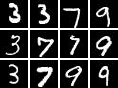

In [7]:
let
    all_imgs = [];
    for d in target_digits
        idxs = findall(memory_labels .== d);
        for i in idxs[1:min(4, length(idxs))]
            push!(all_imgs, Gray.(decode(X_raw[:, i])));
        end
    end
    mosaicview(all_imgs..., nrow=length(target_digits), npad=2, fillvalue=Gray(1.0))
end

### Corrupt a stored memory and retrieve it
We corrupt a stored memory from one class by zeroing out a fraction $\theta$ of its pixels and use deterministic attention to recover it. The key question: does the network retrieve the correct digit class when memories from other classes are also stored?

> __The corruption model:__
>
> We keep the first $(1-\theta)\cdot N$ pixels from the original image and set the remaining $\theta\cdot N$ pixels to $0$. We apply this corruption to both the raw image (for display) and the normalized image (for the update), then run the deterministic update to convergence.

Let's corrupt one memory from each digit class and attempt retrieval.

In [8]:
β_retrieval = 10.0;
T_retrieval = 100;

retrieval_results = let
    cutoff = round(Int, (1 - θ) * number_of_pixels);
    results = [];

    for d in target_digits
        # pick the first memory from this class
        idx = findfirst(memory_labels .== d);

        # corrupt the normalized version
        ŝ = copy(X[:, idx]);
        ŝ[(cutoff+1):end] .= 0.0f0;

        # corrupt the raw version (for display)
        s_raw_corrupt = copy(X_raw[:, idx]);
        s_raw_corrupt[(cutoff+1):end] .= 0.0f0;

        # run deterministic retrieval
        s_recovered = run_deterministic_attention(X, ŝ, β_retrieval, η, T_retrieval);

        # reconstruct in raw pixel space
        p = softmax(β_retrieval .* (transpose(X) * s_recovered));
        s_display = X_raw * p;

        # classify: which class gets the most attention weight?
        class_weights = Dict{Int, Float64}();
        for c in target_digits
            class_weights[c] = sum(p[memory_labels .== c]);
        end
        predicted_class = argmax(class_weights);

        push!(results, (
            digit = d, idx = idx,
            raw_original = X_raw[:, idx],
            raw_corrupted = s_raw_corrupt,
            raw_recovered = s_display,
            predicted = predicted_class,
            class_weights = class_weights
        ));
    end

    results
end;

Let's compare the original, corrupted, and recovered images for each digit class. Each row shows one class (original, corrupted, recovered from left to right):

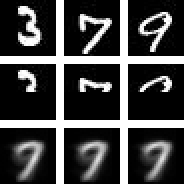

In [9]:
let
    all_imgs = [];
    for r in retrieval_results
        push!(all_imgs, Gray.(decode(r.raw_original)));
        push!(all_imgs, Gray.(decode(r.raw_corrupted)));
        push!(all_imgs, Gray.(decode(r.raw_recovered)));
    end
    mosaicview(all_imgs..., nrow=length(target_digits), npad=4, fillvalue=Gray(1.0))
end

In [10]:
for r in retrieval_results
    correct = r.predicted == r.digit ? "correct" : "WRONG"
    println("Digit $(r.digit): predicted $(r.predicted) ($(correct))")
    for c in target_digits
        w = round(r.class_weights[c], digits=4);
        println("  class $(c) attention weight: $(w)")
    end
end

Digit 3: predicted 7 (WRONG)
  class 3 attention weight: 0.0873
  class 7 attention weight: 0.5275
  class 9 attention weight: 0.3852
Digit 7: predicted 7 (correct)
  class 3 attention weight: 0.0873
  class 7 attention weight: 0.5275
  class 9 attention weight: 0.3852
Digit 9: predicted 7 (WRONG)
  class 3 attention weight: 0.0873
  class 7 attention weight: 0.5275
  class 9 attention weight: 0.3852


### Things to think about
* __Question:__ Does the network retrieve the correct digit class for each corrupted input? How do the attention weights distribute across classes?
* __Question:__ What happens if you increase $\theta$ toward $1.0$? At what corruption level does the network start confusing digit classes?
___

## Task 2: Retrieval Accuracy Across Digit Classes and Beta Values
In this task, we systematically measure how well the network retrieves the correct digit class as a function of $\beta$. For each $\beta$ value, we corrupt several stored memories from each class and classify the retrieval result by nearest-neighbor matching.

> __Classification by attention weight:__
>
> After running the stochastic attention update, we compute the attention weights $\mathbf{p} = \operatorname{softmax}(\beta\mathbf{X}^{\top}\mathbf{s})$ and sum the weights assigned to each digit class. The class with the largest total attention weight is the predicted class. This gives a natural classification rule that leverages the Hopfield network structure.

Let's define the sweep parameters and run the accuracy experiment.

In [11]:
β_values = [50.0, 10.0, 5.0, 2.0, 1.0, 0.5, 0.1]; # inverse temperature sweep
n_trials_per_class = 10;                            # number of corrupted memories to test per class per β

In [12]:
accuracy_table = let

    cutoff = round(Int, (1 - θ) * number_of_pixels);
    results = Vector{NamedTuple{(:β, :digit, :accuracy), Tuple{Float64, Int, Float64}}}();

    for β in β_values
        for d in target_digits
            idxs = findall(memory_labels .== d);
            n_correct = 0;

            for trial in 1:n_trials_per_class
                idx = idxs[trial]; # use different memories for each trial

                # corrupt
                ŝ = copy(X[:, idx]);
                ŝ[(cutoff+1):end] .= 0.0f0;

                # run stochastic attention
                s_final = run_stochastic_attention(X, ŝ, β, η, T_steps);

                # classify by attention weight
                p = softmax(β .* (transpose(X) * s_final));
                class_weights = Dict(c => sum(p[memory_labels .== c]) for c in target_digits);
                predicted = argmax(class_weights);

                if predicted == d
                    n_correct += 1;
                end
            end

            push!(results, (β = β, digit = d, accuracy = n_correct / n_trials_per_class));
        end
    end

    results
end;

Let's display the per-class retrieval accuracy for each $\beta$ value:

In [ ]:
let
    # build a DataFrame for display
    df = DataFrame(
        β = [r.β for r in accuracy_table],
        digit = [r.digit for r in accuracy_table],
        accuracy = [r.accuracy for r in accuracy_table]
    );

    # pivot to wide format: one column per digit class
    wide = unstack(df, :β, :digit, :accuracy);

    # add an overall accuracy column
    wide[!, :overall] = [
        mean([r.accuracy for r in accuracy_table if r.β == β]) for β in β_values
    ];

    pretty_table(
        df;
        backend = :text,
        table_format = TextTableFormat(borders = text_table_borders__compact)
    );
end

Row,β,digit,accuracy
,Float64,Int64,Float64
1,50.0,3,0.6
2,50.0,7,0.4
3,50.0,9,0.6
4,10.0,3,0.4
5,10.0,7,0.5
6,10.0,9,0.5
7,5.0,3,0.4
8,5.0,7,0.1
9,5.0,9,0.4


Let's plot the overall retrieval accuracy as a function of $\beta$:

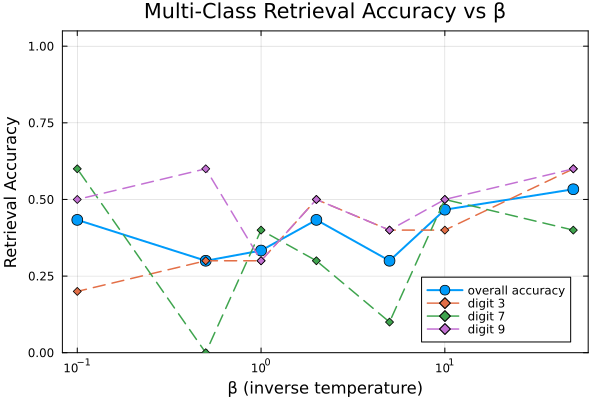

In [14]:
let
    #theme(:dark)
    overall_acc = [mean([r.accuracy for r in accuracy_table if r.β == β]) for β in β_values];

    p = plot(β_values, overall_acc,
        xlabel = "β (inverse temperature)", ylabel = "Retrieval Accuracy",
        title = "Multi-Class Retrieval Accuracy vs β",
        marker = :circle, markersize = 6, linewidth = 2,
        xscale = :log10, legend = :bottomright,
        label = "overall accuracy",
        ylims = (0.0, 1.05), framestyle = :box, grid = true);

    # per-class lines
    for d in target_digits
        acc_d = [r.accuracy for r in accuracy_table if r.digit == d];
        plot!(p, β_values, acc_d, marker = :diamond, markersize = 4,
            linewidth = 1.5, linestyle = :dash, label = "digit $(d)");
    end
    p
end

### Things to think about
* __Question:__ At which $\beta$ value does retrieval accuracy start to drop? How does this relate to the SNR transition from L8a?
* __Question:__ Do some digit classes have higher retrieval accuracy than others? What might cause one class to be easier or harder to retrieve?
___

## Task 3: Mixing Time Analysis
In this task, we track the Langevin trajectory step-by-step and measure how quickly the state converges to a stored memory. We use the cosine similarity between the current state $\mathbf{s}^{t}$ and the nearest stored memory as our convergence metric.

> __Cosine similarity to nearest memory:__
>
> At each step $t$, we compute the cosine similarity between the current state and every stored memory, then take the maximum: $\text{sim}(t) = \max_{k}\,\frac{\mathbf{s}^{t}\cdot\mathbf{x}_{k}}{\lVert\mathbf{s}^{t}\rVert_{2}\,\lVert\mathbf{x}_{k}\rVert_{2}}$. When this value is close to $1$, the state has converged to a stored pattern. The number of steps needed to reach a threshold similarity gives the mixing time.

We use `run_stochastic_attention_trajectory(...)` from `src/Compute.jl` to record the full state at every step. Let's set the parameters and run the trajectories.

In [15]:
β_mixing = [50.0, 10.0, 2.0, 0.5];  # β values to compare
T_mixing = 300;                       # steps to track
n_trajectories = 5;                   # independent runs per β

In [16]:
similarity_curves = let

    curves = Dict{Float64, Vector{Vector{Float64}}}();

    for β in β_mixing
        β_curves = Vector{Vector{Float64}}();

        for run in 1:n_trajectories
            # random initial state
            s_init = randn(Float32, number_of_pixels) .* 0.01f0;

            # get full trajectory: N × (T+1) matrix
            traj = run_stochastic_attention_trajectory(X, s_init, β, η, T_mixing);

            # compute cosine similarity to nearest memory at each step
            sims = Vector{Float64}(undef, T_mixing + 1);
            for t in 1:(T_mixing + 1)
                s_t = traj[:, t];
                s_norm = norm(s_t, 2);
                if s_norm < 1e-10
                    sims[t] = 0.0;
                else
                    # cosine similarity to each memory column
                    cos_sims = (transpose(X) * s_t) ./ (s_norm); # X columns are already unit-norm
                    sims[t] = maximum(cos_sims);
                end
            end
            push!(β_curves, sims);
        end
        curves[β] = β_curves;
    end

    curves
end;

Let's plot the cosine similarity to the nearest memory as a function of step number. Each thin line is an independent trajectory, and the thick line is the mean across trajectories:

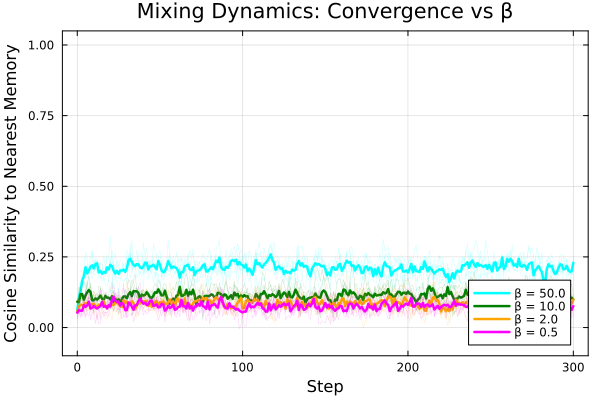

In [17]:
let
    # theme(:dark)
    steps = 0:T_mixing;

    p = plot(xlabel = "Step", ylabel = "Cosine Similarity to Nearest Memory",
        title = "Mixing Dynamics: Convergence vs β",
        framestyle = :box, grid = true, legend = :bottomright, ylims = (-0.1, 1.05));

    colors = [:cyan, :green, :orange, :magenta];
    for (i, β) in enumerate(β_mixing)
        all_curves = similarity_curves[β];
        mean_curve = mean(hcat(all_curves...), dims=2) |> vec;

        # plot individual trajectories (thin, transparent)
        for curve in all_curves
            plot!(p, steps, curve, color = colors[i], alpha = 0.2, linewidth = 0.5, label = nothing);
        end

        # plot mean (thick)
        plot!(p, steps, mean_curve, color = colors[i], linewidth = 2.5, label = "β = $(β)");
    end
    p
end

Let's compute the mixing time for each $\beta$ value. We define mixing time as the first step where the mean cosine similarity exceeds $0.9$:

In [18]:
let
    sim_threshold = 0.9;

    mixing_times = Vector{NamedTuple{(:β, :mixing_time, :final_similarity), 
        Tuple{Float64, Union{Int,String}, Float64}}}();

    for β in β_mixing
        all_curves = similarity_curves[β];
        mean_curve = mean(hcat(all_curves...), dims=2) |> vec;

        # find first step exceeding threshold
        idx = findfirst(mean_curve .>= sim_threshold);
        mt = idx === nothing ? "not reached" : idx - 1; # subtract 1 because index 1 = step 0

        push!(mixing_times, (
            β = β,
            mixing_time = mt,
            final_similarity = round(mean_curve[end], digits=4),
        ));
    end

    pretty_table(mixing_times;
        backend = :text,
    )
end

┌─────────┬──────────────────┬──────────────────┐
│       β │      mixing_time │ final_similarity │
│ Float64 │ U{Int64, String} │          Float64 │
├─────────┼──────────────────┼──────────────────┤
│    50.0 │      not reached │           0.2289 │
│    10.0 │      not reached │           0.0993 │
│     2.0 │      not reached │            0.099 │
│     0.5 │      not reached │           0.0759 │
└─────────┴──────────────────┴──────────────────┘


### Things to think about
* __Question:__ How does the mixing time change as $\beta$ decreases? Does the state always converge to a stored memory at low $\beta$?
* __Question:__ For the low-$\beta$ trajectories, does the cosine similarity plateau at a value below $1.0$? What does this imply about the generated samples?
___

## Summary
This lab extended the stochastic attention example from L8a by storing multiple digit classes in a single Hopfield memory matrix and analyzing retrieval accuracy and convergence dynamics as a function of $\beta$.

> __Key Takeaways__
>
> * **Multi-class retrieval via attention weights:** The modern Hopfield network retrieves the correct digit class from corrupted inputs even when multiple classes share the memory matrix. The softmax attention weights concentrate on memories from the matching class at high $\beta$.
> * **Beta controls retrieval accuracy:** Retrieval accuracy is high when $\beta$ is large and drops as $\beta$ decreases past the SNR transition threshold. This provides a quantitative link between the inverse temperature parameter and network performance.
> * **Mixing time depends on beta:** High $\beta$ trajectories converge to stored memories in fewer steps, while low $\beta$ trajectories converge slowly or plateau at lower similarity values. The mixing time analysis provides a step-level view of the retrieval-generation transition.

The multi-class setting and trajectory analysis provide tools for evaluating Hopfield network performance beyond single-class retrieval.
___